In [ ]:
# --- Colab setup (auto-inserted; no-op outside Colab). tag: colab-bootstrap ---
import sys
if "google.colab" in sys.modules:
    import os, subprocess, pathlib
    _slug = "aniryou/full-stack-agentic-engineer"
    _root = pathlib.Path("/content") / "full-stack-agentic-engineer"
    if not _root.exists():
        subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{_slug}.git", str(_root)], check=True)
    os.chdir(_root / "07-application-agent-framework/retrieval-rag/embeddings-lab/notebooks")
    for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (_c / "pyproject.toml").exists() or (_c / "setup.py").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(_c)]); break
        if (_c / "requirements.txt").exists():
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(_c / "requirements.txt")]); break
        if _c == _root:
            break
    if str(pathlib.Path.cwd()) not in sys.path:
        sys.path.insert(0, str(pathlib.Path.cwd()))


# 01 · From counts to vectors
**One idea:** an embedding is a low-rank factorization of a co-occurrence matrix.
We build PPMI + SVD vectors, then skip-gram with negative sampling (SGNS) from
scratch in NumPy, and verify Levy & Goldberg (2014): SGNS implicitly factorizes
`PMI − log k`. *Primer §1–2.*

In [1]:
import numpy as np, matplotlib.pyplot as plt
from collections import Counter
rng = np.random.default_rng(0)

lines = [l.split() for l in open("../data/tiny_corpus.txt")]
counts = Counter(w for l in lines for w in l)
vocab = sorted(w for w, c in counts.items() if c >= 5)
w2i = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"{V} word types, {sum(counts.values()):,} tokens")

127 word types, 171,964 tokens


## Count co-occurrences (symmetric window)

In [2]:
WINDOW = 4
C = np.zeros((V, V))
for toks in lines:
    ids = [w2i[t] for t in toks if t in w2i]
    for i, wi in enumerate(ids):
        for j in range(max(0, i - WINDOW), min(len(ids), i + WINDOW + 1)):
            if j != i:
                C[wi, ids[j]] += 1
print("co-occurrence matrix:", C.shape, "| nonzero:", int((C > 0).sum()))

co-occurrence matrix: (127, 127) | nonzero: 3947


## PPMI: association beyond chance
Raw counts are dominated by frequency; PMI normalizes it away. Unseen pairs and
negative PMI are clipped to zero — a sparse matrix of "surprising" associations.

In [3]:
def ppmi(C):
    total = C.sum()
    pw = C.sum(1, keepdims=True) / total
    pc = C.sum(0, keepdims=True) / total
    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log((C / total) / (pw * pc))
    pmi[~np.isfinite(pmi)] = 0.0
    return np.maximum(pmi, 0.0)

P = ppmi(C)

## Low-rank factorization = embeddings (this is LSA's trick)
Truncated SVD of PPMI. Rows of `U_d · sqrt(S_d)` are word vectors. By
Eckart–Young this is the best rank-`d` least-squares approximation.

In [4]:
U, S, _ = np.linalg.svd(P)
d = 32
W_svd = U[:, :d] * np.sqrt(S[:d])

def normed(X):
    return X / np.linalg.norm(X, axis=1, keepdims=True)

def neighbours(W, word, k=6):
    Z = normed(W)
    sims = Z @ Z[w2i[word]]
    order = np.argsort(-sims)
    return [(vocab[i], round(float(sims[i]), 2)) for i in order[1 : k + 1]]

for w in ["king", "dog", "coffee", "hammer", "snow"]:
    print(f"{w:>7} → {neighbours(W_svd, w)}")

   king → [('queen', 0.78), ('prince', 0.34), ('lord', 0.28), ('kingdom', 0.26), ('throne', 0.25), ('the', 0.24)]
    dog → [('fish', 1.0), ('goat', 1.0), ('bird', 1.0), ('horse', 1.0), ('cow', 1.0), ('cat', 0.99)]
 coffee → [('rice', 1.0), ('stew', 1.0), ('honey', 1.0), ('tea', 0.99), ('apple', 0.99), ('cheese', 0.99)]
 hammer → [('chisel', 1.0), ('anvil', 1.0), ('plough', 1.0), ('rope', 0.99), ('wheel', 0.99), ('ladder', 0.99)]
   snow → [('cloud', 1.0), ('sun', 1.0), ('storm', 1.0), ('wind', 1.0), ('rain', 1.0), ('mist', 1.0)]


## SGNS from scratch (~35 lines)
For each observed (center, context) pair, push their vectors together; push the
center away from `K` sampled negatives (unigram^0.75). The gradients are just
sigmoid residuals times the other vector. One engineering wrinkle: our vocab is
tiny, so a 1024-pair batch hits the same rows dozens of times — summed scatter
updates explode. We accumulate a *dense mean gradient* and let Adam's
per-parameter scaling absorb the frequency imbalance (the reason sparse-Adam
exists).

In [5]:
freq = np.array([counts[w] for w in vocab], float)
freq /= freq.sum()
keep_p = np.minimum(1.0, np.sqrt(1e-3 / freq))   # word2vec subsampling of frequent words

pairs = []
for toks in lines:
    ids = [w2i[t] for t in toks if t in w2i and rng.random() < keep_p[w2i[t]]]
    for i, wi in enumerate(ids):
        for j in range(max(0, i - WINDOW), min(len(ids), i + WINDOW + 1)):
            if j != i:
                pairs.append((wi, ids[j]))
pairs = np.array(pairs)
uni = freq ** 0.75
uni /= uni.sum()
print(f"{len(pairs):,} training pairs (after subsampling)")

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

D_EMB, K, B, EPOCHS, LR = 32, 5, 1024, 10, 0.02
r2 = np.random.default_rng(1)
Win = r2.normal(0, 0.05, (V, D_EMB))
Wout = np.zeros((V, D_EMB))
mI = vI = mO = vO = 0.0
t = 0
for epoch in range(EPOCHS):
    r2.shuffle(pairs)
    tot = n = 0
    for s in range(0, len(pairs), B):
        ctr, ctx = pairs[s : s + B, 0], pairs[s : s + B, 1]
        neg = r2.choice(V, size=(len(ctr), K), p=uni)
        v, upos, uneg = Win[ctr], Wout[ctx], Wout[neg]
        spos = sigmoid((v * upos).sum(1))                  # want → 1
        sneg = sigmoid(np.einsum("bd,bkd->bk", v, uneg))   # want → 0
        tot += -np.log(spos + 1e-9).sum() - np.log(1 - sneg + 1e-9).sum()
        n += len(ctr)
        gpos, gneg = (spos - 1.0) / len(ctr), sneg / len(ctr)
        GI, GO = np.zeros_like(Win), np.zeros_like(Wout)
        np.add.at(GI, ctr, gpos[:, None] * upos + np.einsum("bk,bkd->bd", gneg, uneg))
        np.add.at(GO, ctx, gpos[:, None] * v)
        np.add.at(GO, neg, gneg[..., None] * v[:, None, :])
        t += 1
        mI = 0.9 * mI + 0.1 * GI; vI = 0.999 * vI + 0.001 * GI**2
        mO = 0.9 * mO + 0.1 * GO; vO = 0.999 * vO + 0.001 * GO**2
        Win -= LR * (mI / (1 - 0.9**t)) / (np.sqrt(vI / (1 - 0.999**t)) + 1e-8)
        Wout -= LR * (mO / (1 - 0.9**t)) / (np.sqrt(vO / (1 - 0.999**t)) + 1e-8)
    if epoch % 3 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch}  loss/pair {tot/n:.3f}")
for w in ["king", "dog", "coffee"]:
    print(f"{w:>7} → {neighbours(Win, w)}")

285,312 training pairs (after subsampling)
epoch 0  loss/pair 2.017
epoch 3  loss/pair 1.778
epoch 6  loss/pair 1.773
epoch 9  loss/pair 1.774
   king → [('queen', 0.95), ('kingdom', 0.95), ('throne', 0.92), ('palace', 0.73), ('royal', 0.69), ('crown', 0.69)]
    dog → [('feeds', 0.7), ('fur', 0.7), ('barks', 0.67), ('farm', 0.67), ('pet', 0.67), ('cat', 0.66)]
 coffee → [('bowl', 0.73), ('pot', 0.7), ('eats', 0.69), ('bakes', 0.69), ('cup', 0.69), ('kitchen', 0.68)]


## The Levy–Goldberg check
At the SGNS optimum, `w·c = PMI(w,c) − log K`. Let's see how close 6 epochs got.

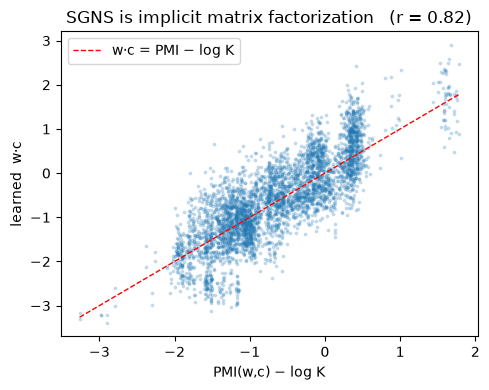

correlation r = 0.818


In [6]:
total = C.sum()
pw, pc = C.sum(1) / total, C.sum(0) / total
mask = C >= 10                                # well-estimated pairs only
pmi_obs = np.log((C[mask] / total) / np.outer(pw, pc)[mask])
dots = (Win @ Wout.T)[mask]
target = pmi_obs - np.log(K)
r = np.corrcoef(dots, target)[0, 1]
plt.figure(figsize=(5, 4))
plt.scatter(target, dots, s=3, alpha=0.2)
lim = [target.min(), target.max()]
plt.plot(lim, lim, "r--", lw=1, label="w·c = PMI − log K")
plt.xlabel("PMI(w,c) − log K"); plt.ylabel("learned  w·c")
plt.title(f"SGNS is implicit matrix factorization   (r = {r:.2f})")
plt.legend(); plt.tight_layout(); plt.show()
print(f"correlation r = {r:.3f}")

## Linear structure: the analogy test
The corpus has a gender × royalty grid, so `king − man + woman` should land on
`queen` (inputs excluded, as is standard — see Linzen 2016 for why that
matters). SVD-PPMI factorizes clean full-corpus statistics and nails both;
10 epochs of stochastic SGNS is noisier — a reminder that analogy accuracy
was always a fragile metric.

In [7]:
def analogy(a, b, c, W):
    Z = normed(W)
    t = Z[w2i[a]] - Z[w2i[b]] + Z[w2i[c]]
    t /= np.linalg.norm(t)
    for i in np.argsort(-(Z @ t)):
        if vocab[i] not in {a, b, c}:
            return vocab[i]

for W, name in [(W_svd, "SVD-PPMI"), (Win, "SGNS")]:
    print(f"{name:>8}: king − man + woman = {analogy('king','man','woman',W)}"
          f" | prince − boy + girl = {analogy('prince','boy','girl',W)}")

SVD-PPMI: king − man + woman = queen | prince − boy + girl = princess
    SGNS: king − man + woman = queen | prince − boy + girl = princess


In [8]:
import os
os.makedirs("../artifacts", exist_ok=True)
np.savez("../artifacts/word_vectors.npz", W_svd=W_svd, W_sgns=Win,
         vocab=np.array(vocab), C=C)
print("saved → artifacts/word_vectors.npz")

saved → artifacts/word_vectors.npz


**Takeaways.** (1) Count → PPMI → SVD already gives usable embeddings; word2vec
is the same factorization with a better loss. (2) Similarity and analogies are
properties of the *co-occurrence statistics*, not of neural magic. (3) Everything
downstream — sentence encoders, CLIP, recommenders — repeats this pattern with
richer context definitions. → Exercises: `exercises/ex01.ipynb`.